In [1]:
import sys, os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

HERE = Path(os.path.abspath(""))
ROOT = HERE.parent.parent.parent if HERE.name == "verify_gas_drag" else HERE
sys.path.insert(0, str(ROOT))

from spacehub_calc import load_spacehub_data_live, TwoBodyOrbit

In [2]:
def load_orbits(pattern):
    """Load simulation outputs, tolerant of incomplete/in-progress files.
    
    Automatically detects and concatenates '-resumed.dat' continuations.
    """
    orbits = {}
    for fpath in sorted(glob.glob(str(HERE / pattern))):
        if "FAILED" in fpath or "-resumed" in fpath:
            continue
        stem = Path(fpath).stem
        inc = float(stem.split("incl-")[-1])
        df = load_spacehub_data_live(fpath)
        if df is None or len(df) <= 2:
            continue

        # Check for a matching resumed file
        resumed_path = fpath.replace(".dat", "-resumed.dat")
        if os.path.exists(resumed_path):
            df_resumed = load_spacehub_data_live(resumed_path)
            if df_resumed is not None and len(df_resumed) > 2:
                df = pd.concat([df, df_resumed], ignore_index=True)
                # Deduplicate by (time, id) — NOT just time, since SpaceHub writes
                # one row per particle per timestep (all sharing the same time value).
                df = df.drop_duplicates(subset=["time", "id"], keep="last")
                df = df.sort_values("time").reset_index(drop=True)

        orbits[inc] = TwoBodyOrbit.from_dataframe(df, mute=True)
    return orbits

orbits_low  = load_orbits("ZengLowEcc-pagn/incl-*.dat")
orbits_high = load_orbits("ZengHighEcc-pagn/incl-*.dat")
print(f"Low-ecc  (e=0.3): {sorted(orbits_low)}")
print(f"High-ecc (e=0.7): {sorted(orbits_high)}")

Calculated c0 values are within 65.5 of constant (maximum - minimum)
Calculated c0 values are within 54.65 of constant (maximum - minimum)
Calculated c0 values are within 52.83 of constant (maximum - minimum)
Calculated c0 values are within 2.27e+06 of constant (maximum - minimum)
Calculated c0 values are within 173.3 of constant (maximum - minimum)
Calculated c0 values are within 15.17 of constant (maximum - minimum)
Calculated c0 values are within 342.9 of constant (maximum - minimum)
Calculated c0 values are within 204.5 of constant (maximum - minimum)
Low-ecc  (e=0.3): [5.0, 45.0, 120.0, 135.0]
High-ecc (e=0.7): [45.0, 120.0, 135.0, 170.0]


| Parameter | Value |
|-----------|-------|
| M_SMBH | 1e8 M_sun |
| m_SMO | 30 M_sun (sBH) |
| Disk model | Sirko & Goodman (pagn) |
| alpha | 0.1 |
| l_e (Mdot/Mdot_Edd) | 0.5 |
| eps (radiative efficiency) | 0.1 |
| p_ini | 300 Rg |
| Force | Dynamical friction only |
| Inclinations | 20, 45, 90, 105, 120, 135, 170 deg |

In [3]:
# Geometrized length unit: GM/c^2 for M = 1e8 Msun, in AU
Mbullet_AU = 0.9853

# Geometrized time unit: T_M = GM/c^3  (in years)
# GM_sun/c^3 = 4.9255e-6 s
M_SMBH_Msun = 1e8
T_M_seconds = 4.9255e-6 * M_SMBH_Msun
T_M_years = T_M_seconds / 3.15576e7  # seconds per Julian year

def plot_zengpan(orbits_dict, e0, fignum):
    if not orbits_dict:
        print(f"No data for e={e0}")
        return None

    cmap = cm.rainbow
    incs = sorted(orbits_dict)
    norm = plt.Normalize(vmin=min(incs), vmax=max(incs))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

    for inc in incs:
        orb = orbits_dict[inc]
        t_Mbullet = orb.years / T_M_years        # t in M_bullet units
        a_Mbullet = np.array(orb.semiMajorAxis) / Mbullet_AU  # a in M_bullet
        e = np.array(orb.eccentricity)
        I = np.array(orb.inclination_deg)
        c = cmap(norm(inc))
        ls = '-' if inc < 90 else '--'
        lbl = f"{inc:.0f}°"

        axes[0].plot(t_Mbullet, a_Mbullet, color=c, lw=1.2, ls=ls, label=lbl)
        axes[1].plot(t_Mbullet, e, color=c, lw=1.2, ls=ls)
        axes[2].plot(t_Mbullet, I, color=c, lw=1.2, ls=ls)

    # Reference lines
    axes[0].axhline(10, color='blue', ls=':', lw=0.8, alpha=0.6)
    axes[2].axhline(90, color='black', ls=':', lw=0.8, alpha=0.6)

    axes[0].set(ylabel=r'$a\ [M_\bullet]$', xlabel=r'$t\ [M_\bullet]$')
    axes[1].set(ylabel=r'$e$', yscale='log', xlabel=r'$t\ [M_\bullet]$')
    axes[2].set(ylabel=r'$\iota\ [\mathrm{deg}]$', xlabel=r'$t\ [M_\bullet]$')
    for ax in axes:
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3)

    axes[0].legend(fontsize=8, ncol=2, loc='lower left')
    fig.suptitle(f'Fig {fignum}: Dynamical Friction, $e_{{\\mathrm{{ini}}}}={e0}$, $p_{{\\mathrm{{ini}}}}=300\\,M_\\bullet$',
                 fontsize=12)
    fig.tight_layout()
    return fig

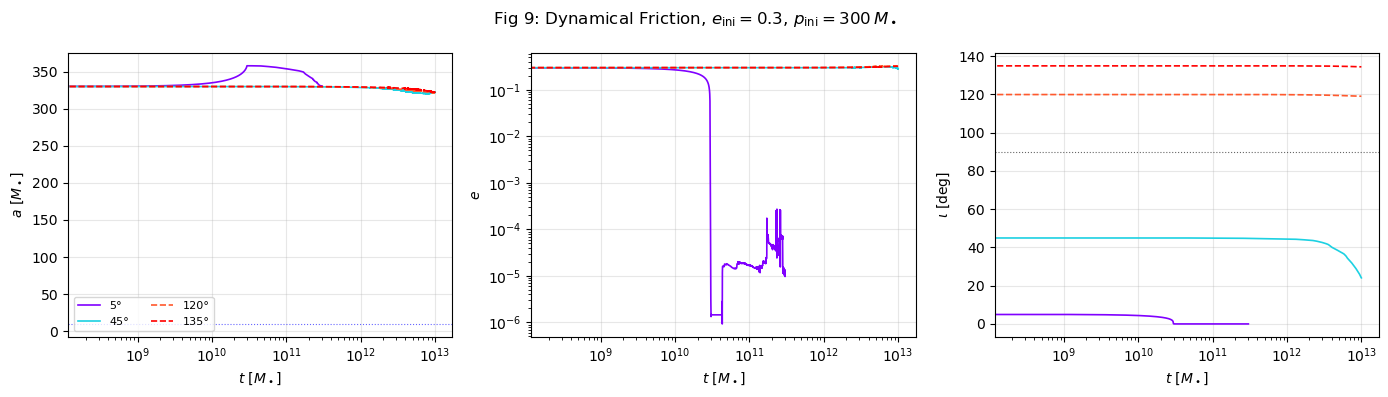

In [4]:
fig9 = plot_zengpan(orbits_low, e0=0.3, fignum=9)
plt.show()

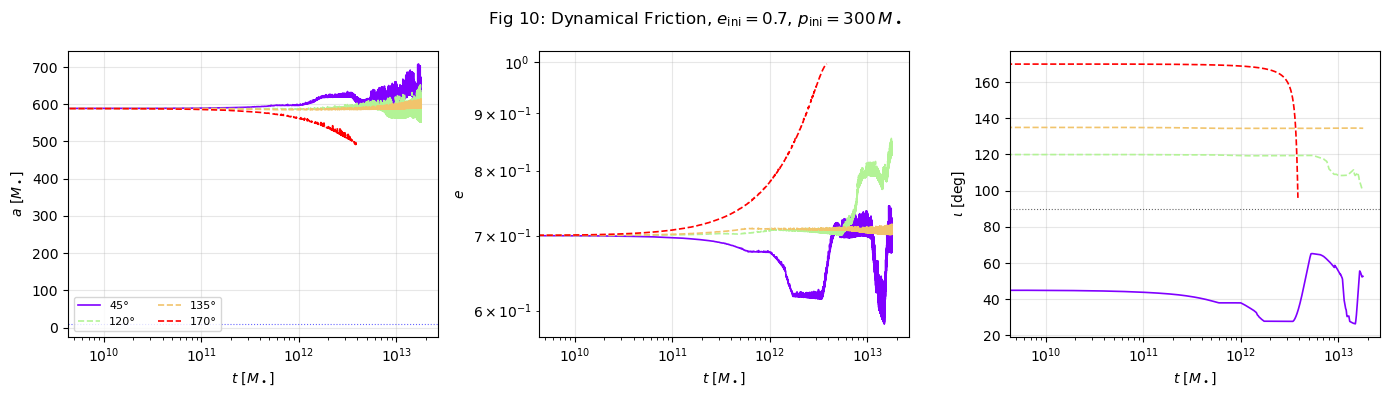

In [5]:
fig10 = plot_zengpan(orbits_high, e0=0.7, fignum=10)
plt.show()